## Designing structures for an uncertain future - numerical investigations

This code investigates optimal design choices for structural design for safety considering uncertain future changes.
It accompagnies the paper 

"Straub D. (2026). Designing structures for an uncertain future. Proc. IABSE Congress 2026 – Structural Engineering Towards Evolution and Hyper-Expansion, Incheon, South Korea"


In [415]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd

# %pip install eraUQ # Uncomment if eraUQ not installed
from eraUQ import ERADist, EmpDist, ERACond, ERANataf, ERARosen


In [416]:
# General settings

# Define the general parameters of the decision problem
T_life = 100; # Lifetime of the system in years
DT = 10; # Time step in years
r = 0.0; # Annual discount rate
def discount(i):
    return 1 / (1 + r) ** i

# Safety and reliability parameters
Beta_target = 4.3; # Annual target reliability index
gamma_R = 1.2; # Partial factor for resistance
gamma_S = 1.5; # Partial factor for load effect
Rk_quantile = 0.05; # Quantile for resistance
Sk_quantile = 0.98; # Quantile for load effect

# Random number generation settings
seed = 12345; # Random seed for reproducibility
rng = np.random.default_rng(seed) # Random number generator


### Cost model and flexibility

We use the following cost model: The for the initial design and/or strengthening is 
$$C = c_0 + c_1*\Delta r$$
in which $\Delta r$ is the increase in resistance

To determine $c_0$ and $c_1$, we set the flexibility parameter following Straub and Spackova (2017). Furthermore, we fix the cost of the initial construction to 1.

The cost of failure is set to $c_F = 1000$.

The flexibilty is $$\varphi = \frac{c_1\times r_1}{c_0+c_1\times r_1}$$

with $r_1$ being the initial resistance.

It follows that
$$\frac{c_0}{c_1} = r_1 \times (\frac{1}{\varphi}-1)$$

Together with $c_0 + c_1\times r_1 = 1$ we get
$$c_1 = \frac{\varphi}{r_1}$$
$$c_0 = 1-\varphi$$

As the base case, we choose $\varphi=0.1$

In [417]:
# Cost model: 
Flexibility = 0.9
c_F = 1e3;

r_init = 70 # This is the approximate initial resistance (for a reserver factor of 2)

def cost_model(Flexibility, r_init):
    c_1 = Flexibility/r_init
    c_0 = 1-Flexibility
    return c_0, c_1

c_0, c_1 = cost_model(Flexibility, r_init)
print(f"Cost model parameters of the base case: c_0 = {c_0:.4f}, c_1 = {c_1:.4f}")


Cost model parameters of the base case: c_0 = 0.1000, c_1 = 0.0129


### Case 1: Basic problem assuming that the probabilistic models are perfect

Failure in year $i$ is descibed by the limit state function $g(X) = R - S_i$

$S_i$ are independent among different years, whereas $R$ is constant (unless the structure is modified). Both are modeled as lognormal random variables.

The mean value of $S_i$ modeled by gamma process, whereas the standard deviation of $S_i$, and the moments of $R$, are constant values. $mu_R$ is determined from the design criteria to match the target reliability.

<ipython-input-448-7efc910ff9fb>:65: UserWarning: Matplotlib is currently using svg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


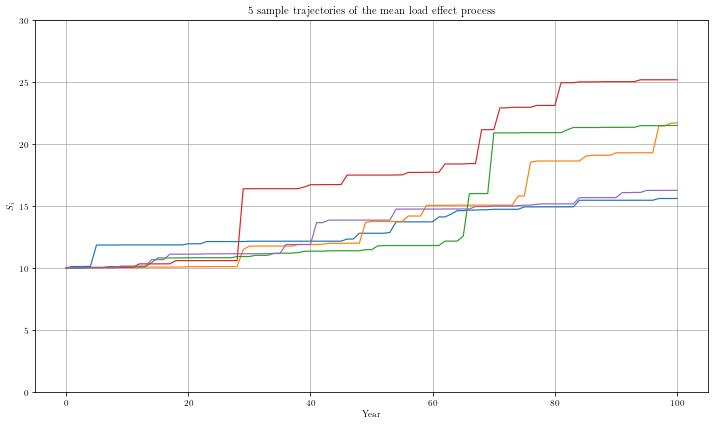

In [448]:
## Define the probabilistic load model

# Constant values
COV_R = 0.15; # C.O.V. of the log resistance
COV_S = 0.3; # C.O.V. of the log load effect
sigma_lnR = np.sqrt(np.log(1 + COV_R**2)); # Standard deviation of the log resistance
sigma_lnS = np.sqrt(np.log(1 + COV_S**2)); # Standard deviation of the log load effect

# Gamma process for the mean load effect S_i
# Define the mean function
def load_mean_function(i):
    return 10 + i / 10

# Define the COV of the Gamma distribution for each jump:
gamma_cov = 5

def gamma_process(T_life, load_mean_function, gamma_cov, n):
    """
    Simulates n sample trajectories of a Gamma process with T_life steps using vectorized operations.

    Parameters:
        T_life (int): Number of steps in the process.
        mean_function (function): A function defining the mean at each step.
        c (float): COV of the Gamma distribution for each jump.
        n (int): Number of sample trajectories.

    Returns:
        np.ndarray: Simulated Gamma process values for all trajectories.
    """
    # Scale parameter for the Gamma distribution:
    shape_param = 1/gamma_cov**2

    # Create a matrix of shape parameters (mean values) for all steps and trajectories
    mean_values = np.array([load_mean_function(i) for i in range(0, T_life + 1)])
    mean_increments = np.diff(np.hstack(([0], mean_values)))  # Mean increments for each step
    mean_increments = mean_increments[1:] # Exclude the first increment (from 0 to mean_function(0))
    scale_matrix = np.tile(mean_increments/shape_param, (n, 1))  # Shape matrix for all trajectories

    # Generate Gamma-distributed random increments for all steps and trajectories
    increments = np.random.gamma(shape_param, scale=scale_matrix)

    # Add the fixed starting value to the beginning of each trajectory
    increments = np.hstack((np.full((n, 1), load_mean_function(0)), increments))

    # Compute the cumulative sum along the time axis to get the Gamma process
    trajectories = np.cumsum(increments, axis=1)

    return trajectories


# Simulate the Gamma process
n = 5  # Number of sample trajectories
trajectories = gamma_process(T_life, load_mean_function, gamma_cov, n)

# Plot the Gamma process trajectories
plt.figure(figsize=(10, 6))
for j in range(n):
    plt.plot(range(T_life + 1), trajectories[j], label=f"Trajectory {j + 1}")
plt.xlabel("Year")
plt.ylabel("$S_i$")
plt.ylim(0, 30)
plt.title(f"{n} sample trajectories of the mean load effect process")
#plt.legend()
plt.grid()
plt.show()

Next, we compute the initial resistance necessary according to the design criteria, and then we check how the reliability evolves over time for the sample trajectories from above.

In [419]:
# Determine the initial design following the current safety and reliability requirements

# Reliability achieved with design parameters
R_k_req0 = S_k*gamma_R*gamma_S
mu_lnR_req0 = np.log(R_k_req0) - norm.ppf(Rk_quantile)*sigma_lnR # Mean of the log resistance
mu_R_req0 = np.exp(mu_lnR_req0 + 0.5*sigma_lnR**2) # Mean of the resistance
beta_0 = (mu_lnR_req0 - mu_lnS0) / np.sqrt(sigma_lnR**2 + sigma_lnS**2) # Reliability index

# The following part is not used, it's just a sanity check

# Determine the required mean resistance for the initial design according to the reliability criterion
mu_lnS0 = np.log(load_mean_function(0)) - 0.5 * sigma_lnS**2 # Mean of the log load effect at time 0
mu_lnR_req0_alt = Beta_target*np.sqrt(sigma_lnR**2 + sigma_lnS**2) + mu_lnS0 # Required mean resistance

# Determine the corresponding safety factor for the load effect
lnR_k = norm.ppf(Rk_quantile, loc=mu_lnR_req0_alt, scale=sigma_lnR) # Quantile of the resistance
R_k = np.exp(lnR_k) 
lnS_k = norm.ppf(Sk_quantile, loc=mu_lnS0, scale=sigma_lnS) # Quantile of the load effect
S_k = np.exp(lnS_k)
gamma_S_req = R_k/gamma_R/S_k # Required safety factor for the load effect


In [420]:
# Check code compliance:
def check_code_compliance(r_k, mu_S_i):
    """
    Check if the design code requirements are met for the given design resistance and mean load effect.

    Parameters:
        r_d (float): Design resistance.
        mu_S_i (float): Mean load effect at time i.

    Returns:
        bool: True if the design meets the code requirements, False otherwise.
    """
    # Calculate the required design resistance based on the mean load effect and safety factors
    mu_lnS_I = np.log(mu_S_i) - 0.5 * sigma_lnS**2 # Mean of the log load effect
    S_k = np.exp(norm.ppf(Sk_quantile, loc=mu_lnS_I, scale=sigma_lnS)) # Quantile of the load effect
    R_k_req = S_k * gamma_R * gamma_S

    # Check if the design resistance meets or exceeds the required resistance
    return r_k >= R_k_req

In [421]:
# Determine the resistance based on current load effect and safety factors:
def determine_resistance(mu_S_i,w_od):
    """
    Determine the design resistance based on the current mean load effect and safety factors.

    Parameters:
        mu_S_i (float): Mean load effect at time i.
        w_od (float): Reserve capacity.

    Returns:
        float: Design resistance.
    """
    mu_lnS_I = np.log(mu_S_i) - 0.5 * sigma_lnS**2 # Mean of the log load effect
    S_k = np.exp(norm.ppf(Sk_quantile, loc=mu_lnS_I, scale=sigma_lnS)) # Quantile of the load effect
    R_k_req = S_k * gamma_R * gamma_S * w_od # Required characteristic resistance

    mu_lnR_j = np.log(R_k_req) - norm.ppf(Rk_quantile)*sigma_lnR
    mu_R_j = np.exp(mu_lnR_j + 0.5*sigma_lnR**2) # Corresponding mean resistance
    
    return R_k_req,mu_R_j

In [422]:
# Compute the probability of failure
def probability_of_failure(mu_S, mu_R, sigma_lnS, sigma_lnR):
    """
    Calculate the probability of failure given load effect S and resistance R statistics.
    Makes use of the semi-analytical solution for lognormal distributions.

    Parameters:
        mu_S (float): Mean of the load effect S.
        mu_R (float): Mean of the resistance R.
        sigma_lnS (float): Standard deviation of the log load effect S.
        sigma_lnR (float): Standard deviation of the log resistance R.

    Returns:
        float: Probability of failure.
    """
    
    mu_lnR = np.log(mu_R) - 0.5 * sigma_lnR**2 # Mean of the log resistance
    mu_lnS = np.log(mu_S) - 0.5 * sigma_lnS**2 # Mean of the log load effect

    betaRel = (mu_lnR - mu_lnS) / np.sqrt(sigma_lnR**2 + sigma_lnS**2) # Reliability index

    return norm.cdf(-betaRel)

<ipython-input-449-e76dfb97c6fd>:14: UserWarning: Matplotlib is currently using svg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


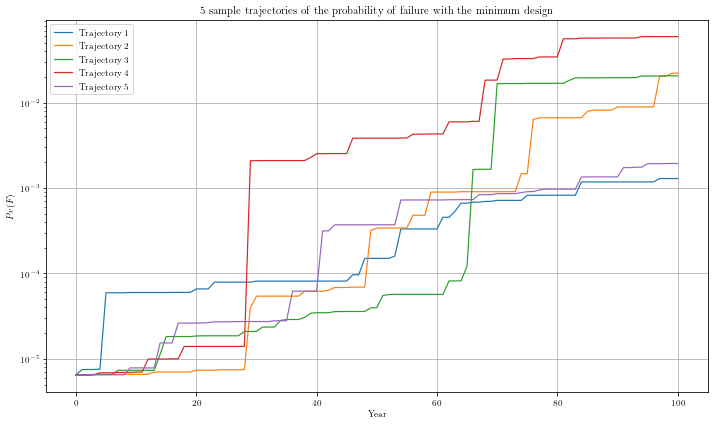

In [449]:
# compute and plot the probabilities of failure corresponding to the trajectories of the mean load effect process
pF_trajectories = probability_of_failure(trajectories, mu_R_req0, sigma_lnS, sigma_lnR)

# Plot the Pr(F) trajectories
plt.figure(figsize=(10, 6))
for j in range(n):
    plt.plot(range(T_life + 1), pF_trajectories[j], label=f"Trajectory {j + 1}")
plt.yscale('log')
plt.xlabel("Year")
plt.ylabel("$Pr(F)$")
plt.title(f"{n} sample trajectories of the probability of failure with the minimum design")
plt.legend()
plt.grid()
plt.show()


### Optimization of the initial design
This optimization assumes a reliability-based design. Whenever the reliability target is not met anymore, the structure must be strengthed to comply with the requirements. We assume that this requirement is no longer valid in the last 10 years in service.

We use a heuristic policy, in which the only parameter to optimize is the overdesign factor $w_{od}$. I.e., the currently necessary resistance is increased by a factor $w_{od}$.
For simplicity, we assume that the same $w_{od}$ is applied at all times.



Expected total cost of the system over its lifetime: 1.11
Expected design cost of the system over its lifetime: 1.11
Expected risk cost of the system over its lifetime: 0.00


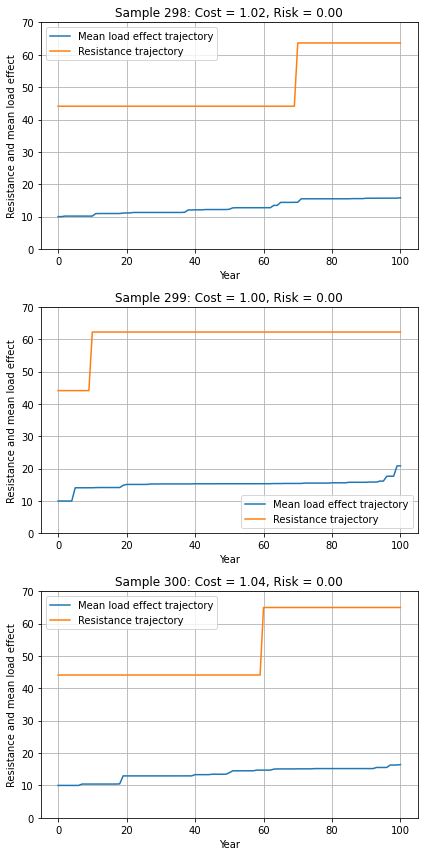

In [ ]:
# Evaluate the expected total cost of the system over its lifetime using MCS
def evaluate_LCC(w_od):
    """
    Evaluate the expected total cost of the system over its lifetime using Monte Carlo Simulation.

    Parameters:
        w_od (float): Reserve capacity.

    Returns:
        tuple: Expected total cost, expected design cost, expected risk cost.
    """

    n_MC = 6000 # Number of Monte Carlo samples
    mu_S_i = gamma_process(T_life, load_mean_function, gamma_cov, n_MC) # Simulate the mean load effect process for Monte Carlo samples

    # Initialize arrays of zeros:
    c_design = np.zeros(n_MC)  # Design cost for each Monte Carlo sample
    risk = np.zeros(n_MC)      # Risk cost for each Monte Carlo sample
    rk_j = np.zeros((n_MC, T_life+1))  # Resistance for each Monte Carlo sample

    for j in range(n_MC):   
        rk_j[j,:],mu_R_j = determine_resistance(mu_S_i[j, 0],w_od) # Apply the reserve capacity to characeristic resistance
        #mu_lnR_j = np.log(rk_j[j,0]) - norm.ppf(Rk_quantile)*sigma_lnR
        #mu_R_j = np.exp(mu_lnR_j + 0.5*sigma_lnR**2)
        c_design[j] = c_0 + c_1 * rk_j[j,0] # Initial design cost
        risk[j] = 0 # Initialize risk cost
        for i in range(T_life + 1):
            risk[j] = risk[j] + discount(i) * probability_of_failure(mu_S_i[j, i], mu_R_j, sigma_lnS, sigma_lnR)
            if i % DT == 0 and i < T_life-10: # Check code compliance every DT years, but not in the last 10 years
                if not check_code_compliance(rk_j[j,i] , mu_S_i[j, i]):
                    rk_j[j,i:],mu_R_j = determine_resistance(mu_S_i[j, i],w_od)
                    DeltaR = rk_j[j,i] - rk_j[j,i-1] 
                    c_design[j] = c_design[j] + discount(i) * (c_0 + c_1*DeltaR) # Add failure cost if code compliance is not met

    return c_design, risk, rk_j, mu_S_i

w_od = 1.4 # reserve capacity
c_design, risk, rk_j, mu_S_i = evaluate_LCC(w_od)

print(f"Expected total cost of the system over its lifetime: {np.mean(c_design + risk):.2f}")
print(f"Expected design cost of the system over its lifetime: {np.mean(c_design):.2f}")
print(f"Expected risk cost of the system over its lifetime: {np.mean(risk):.2f}")    

plt.figure(figsize=(6, 12))  

# Loop through the last 3 sample trajectories
for idx, j in enumerate(range(n_MC - 3, n_MC)):
    plt.subplot(3, 1, idx + 1)  # Create a 2x2 grid of subplots
    plt.plot(range(T_life + 1), mu_S_i[j], label=f"Mean load effect trajectory")
    plt.plot(range(T_life + 1), rk_j[j], label=f"Resistance trajectory")
    plt.xlabel("Year")
    plt.ylabel("Resistance and mean load effect")
    plt.ylim(0, 70)
    plt.title(f"Sample {j + 1}: Cost = {c_design[j]:.2f}, Risk = {risk[j]:.2f}")
    plt.legend()
    plt.grid()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [425]:
# return

Find the optimal reserve capacity in function of flexibility:

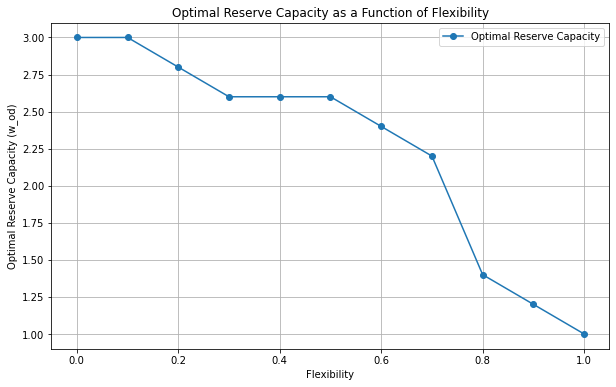

    Flexibility  Optimal Reserve Capacity (w_od)  \
0           0.0                              3.0   
1           0.1                              3.0   
2           0.2                              2.8   
3           0.3                              2.6   
4           0.4                              2.6   
5           0.5                              2.6   
6           0.6                              2.4   
7           0.7                              2.2   
8           0.8                              1.4   
9           0.9                              1.2   
10          1.0                              1.0   

    Minimum Expected Total Cost (ETC)  
0                            1.017013  
1                            1.056824  
2                            1.095297  
3                            1.124706  
4                            1.151956  
5                            1.170457  
6                            1.186220  
7                            1.201642  
8              

In [ ]:
nf=11
nw=11
Flexibility_array = np.linspace(0, 1, nf)  # Start at 0, end at 1 (inclusive), step size 1/nf
w_od_array = np.linspace(1.0, 3.0, nw)  # Start at 1.0, end at 3 (inclusive), step size 2/nw

ETC = np.zeros((nf, nw))  # Initialize the expected total cost matrix
opt_w_od_index = np.zeros(nf, dtype=int)  # Initialize the optimal reserve capacity index array
opt_w_od = np.zeros(nf)  # Initialize the optimal reserve capacity array
min_ETC = np.zeros(nf)  # Initialize the minimum expected total cost array

for k, f in enumerate(Flexibility_array):
    c_0, c_1 = cost_model(f, r_init)
    for l, w in enumerate(w_od_array):
        c_design, risk, rk_j, mu_S_i = evaluate_LCC(w)
        ETC[k,l] = np.mean(c_design + risk)
    opt_w_od_index[k] = np.argmin(ETC[k,:])  
    opt_w_od[k] = w_od_array[opt_w_od_index[k]]
    min_ETC[k] = ETC[k,opt_w_od_index[k]]


# Plot: Optimal Reserve Capacity vs Flexibility
plt.figure(figsize=(10, 6))
plt.plot(Flexibility_array, opt_w_od, marker='o', label="Optimal Reserve Capacity")
plt.xlabel("Flexibility")
plt.ylabel("Optimal Reserve Capacity (w_od)")
plt.title("Optimal Reserve Capacity as a Function of Flexibility")
plt.grid()
plt.legend()
plt.show()

# Create a summary table
summary_data = {
    "Flexibility": Flexibility_array,
    "Optimal Reserve Capacity (w_od)": opt_w_od,
    "Minimum Expected Total Cost (ETC)": min_ETC
}
summary_table = pd.DataFrame(summary_data)

print(summary_table)

# Optionally, save the table to a CSV file
summary_table.to_csv("summary_results.csv", index=False)

In [427]:
c_0, c_1 = cost_model(0.2, r_init)
print(f"Cost model parameters of the base case: c_0 = {c_0:.4f}, c_1 = {c_1:.4f}")

cost = c_0 + c_1 * mu_R_req0 * 2.2
print(f"Cost of the system with a reserve capacity of 2.2: {cost:.2f}")

Cost model parameters of the base case: c_0 = 0.8000, c_1 = 0.0029
Cost of the system with a reserve capacity of 2.2: 1.06


<ipython-input-456-8632a354bc9d>:26: UserWarning: Matplotlib is currently using svg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
<ipython-input-456-8632a354bc9d>:40: UserWarning: Matplotlib is currently using svg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


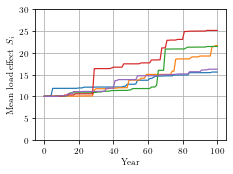

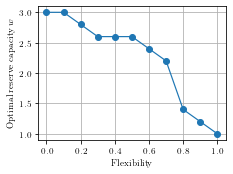

In [ ]:
# Produce figures for publication

import matplotlib


plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,          # match document math typesetting
    "font.size": 9,               # match your document's body size
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.autolayout": True,
})

# Figure of trajectories of the mean load effect process:
plt.figure(figsize=(3.15*1.05, 2.5))
for j in range(n):
    plt.plot(range(T_life + 1), trajectories[j], label=f"Trajectory {j + 1}")
plt.xlabel("Year")
plt.ylabel("Mean load effect $S_i$")
plt.ylim(0, 30)
# plt.title(f"{n} sample trajectories of the mean load effect process")
# plt.legend()
plt.grid()
plt.tight_layout(pad=0.01)   # shrinks internal margins to near-zero, keeps canvas size fixed
plt.show()

matplotlib.use("svg")
plt.rcParams["svg.fonttype"] = "path"   # or "none"
plt.savefig("mean_load_effect_trajectories.svg", bbox_inches="tight", pad_inches=0.02)

# Plot: trajectories with designs for two flexibilities
# Loop through the 3 sample trajectories
plt.figure(figsize=(3.15*1.05, 6.5))

seed = 12345; # Random seed for reproducibility
rng = np.random.default_rng(seed) # Random number generator
c_design_1, risk_1, rk_j_1, mu_S_i_1 = evaluate_LCC(w_od=1.2)
seed = 12345; # Random seed for reproducibility
rng = np.random.default_rng(seed) # Random number generator
c_design_2, risk_2, rk_j_2, mu_S_i_2 = evaluate_LCC(w_od=2,8)

for idx, j in enumerate(range(n_MC - 3, n_MC)):
    plt.subplot(3, 1, idx + 1)  # Create a 2x2 grid of subplots
    plt.plot(range(T_life + 1), mu_S_i_1[j], label=f"Mean load effect")
    plt.plot(range(T_life + 1), rk_j_1[j], label=f"Optimal resistance for $\varphi=0.8")
    plt.plot(range(T_life + 1), rk_j_2[j], label=f"Optimal resistance for $\varphi=0.1")
    plt.xlabel("Year")
    plt.ylabel("Resistance and mean load effect")
    plt.ylim(0, 70)
    plt.title(f"Sample {j + 1}: Cost = {c_design[j]:.2f}, Risk = {risk[j]:.2f}")
    plt.legend()
    plt.grid()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Plot: Optimal Reserve Capacity vs Flexibility
plt.figure(figsize=(3.15*1.05, 2.5))
plt.plot(Flexibility_array, opt_w_od, marker='o', label="Optimal Reserve Capacity")
plt.xlabel("Flexibility")
plt.ylabel("Optimal reserve capacity $w$")
# plt.title("Optimal reserve capacity as a Function of Flexibility")
plt.grid()
plt.tight_layout(pad=0.01)   # shrinks internal margins to near-zero, keeps canvas size fixed
plt.show()

matplotlib.use("svg")
plt.rcParams["svg.fonttype"] = "path"   # or "none"
plt.savefig("optimal_capacity.svg", bbox_inches="tight", pad_inches=0.02)

